In [3]:
import numpy as np

trajectory_data = np.load('./trajectory_data.npy', allow_pickle=True)
print(trajectory_data.shape)

(485, 1000, 18)


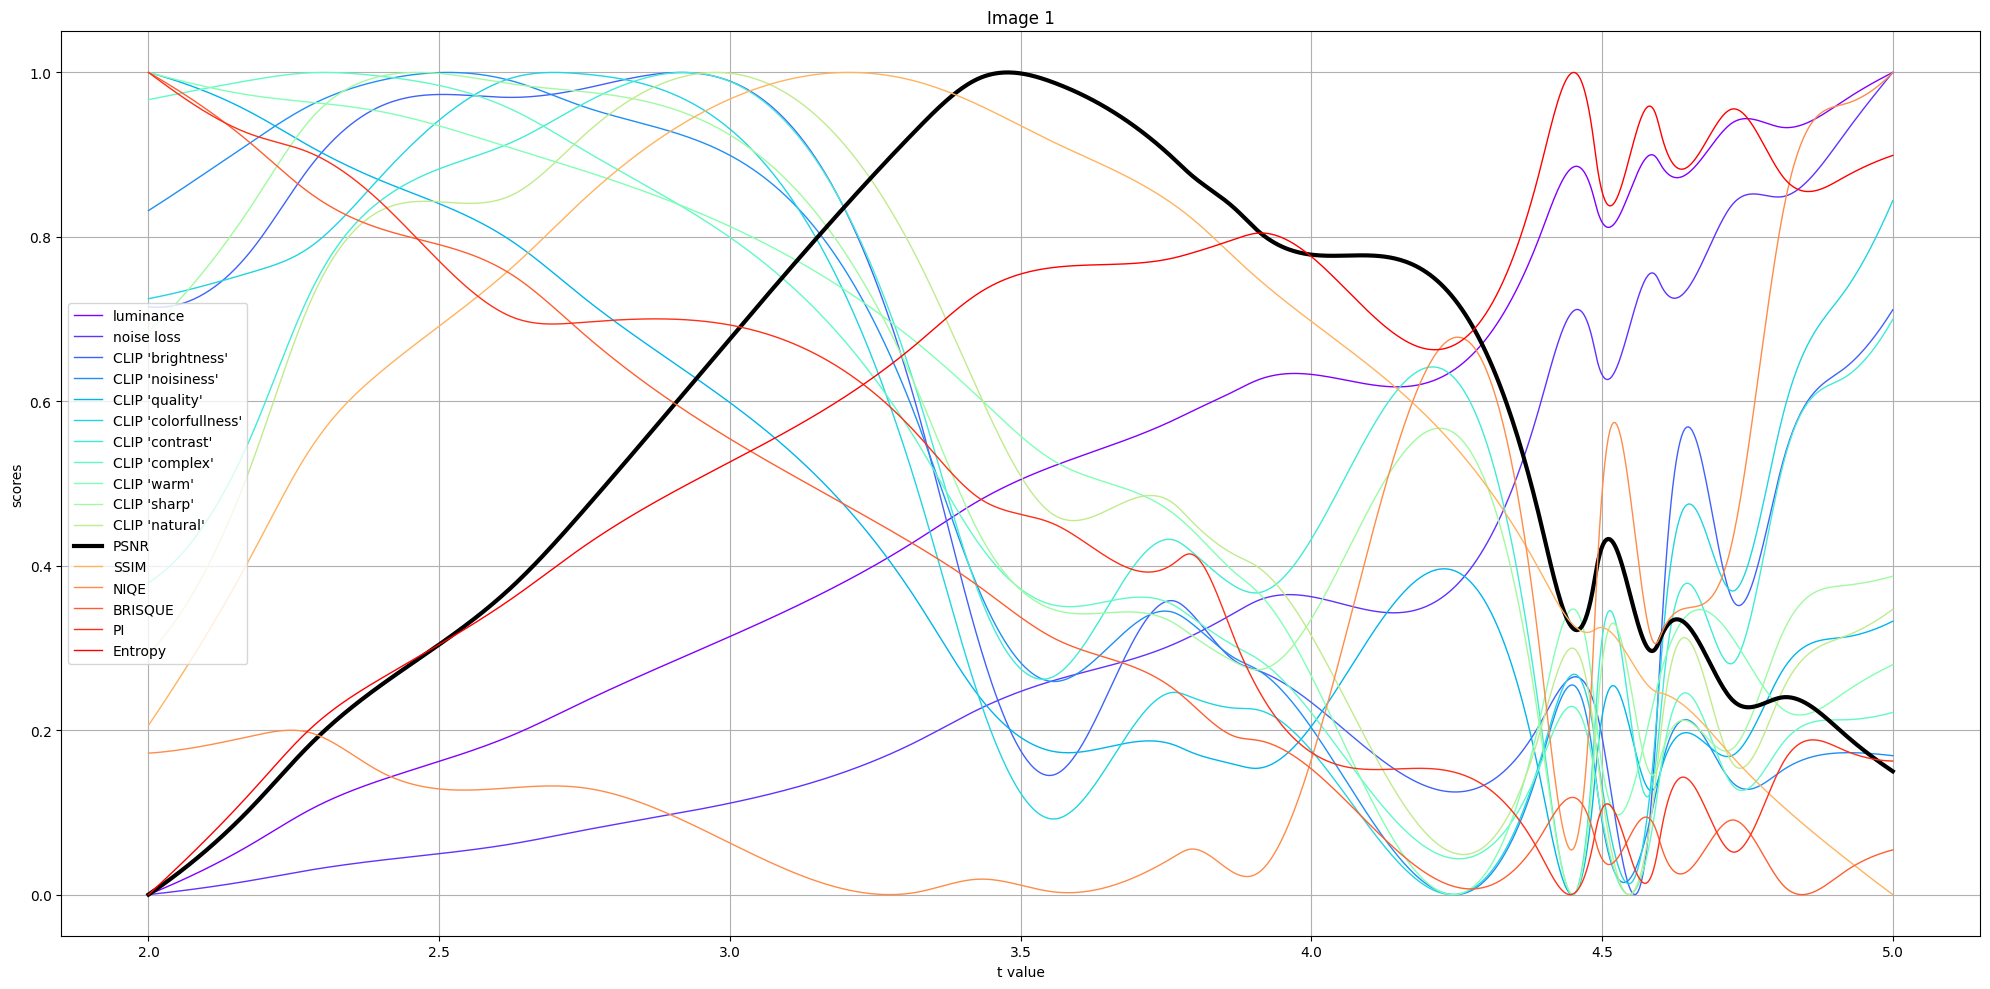

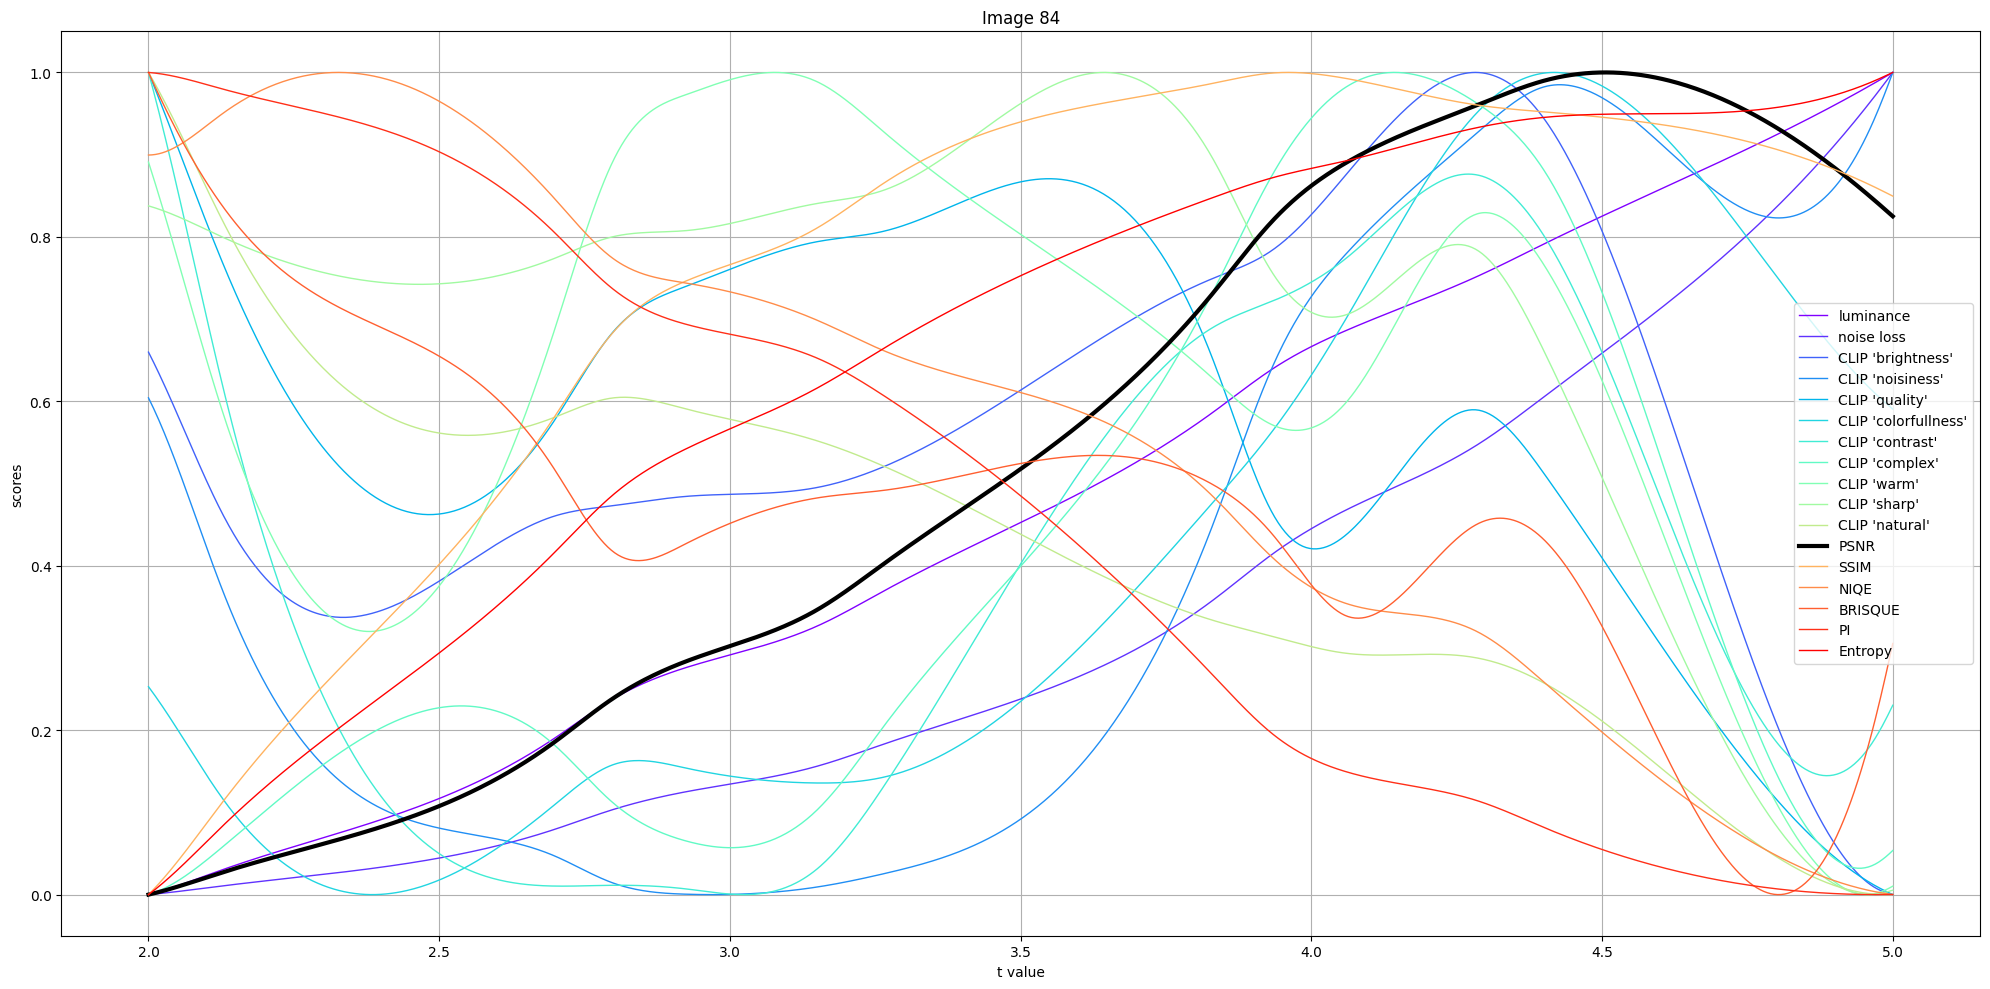

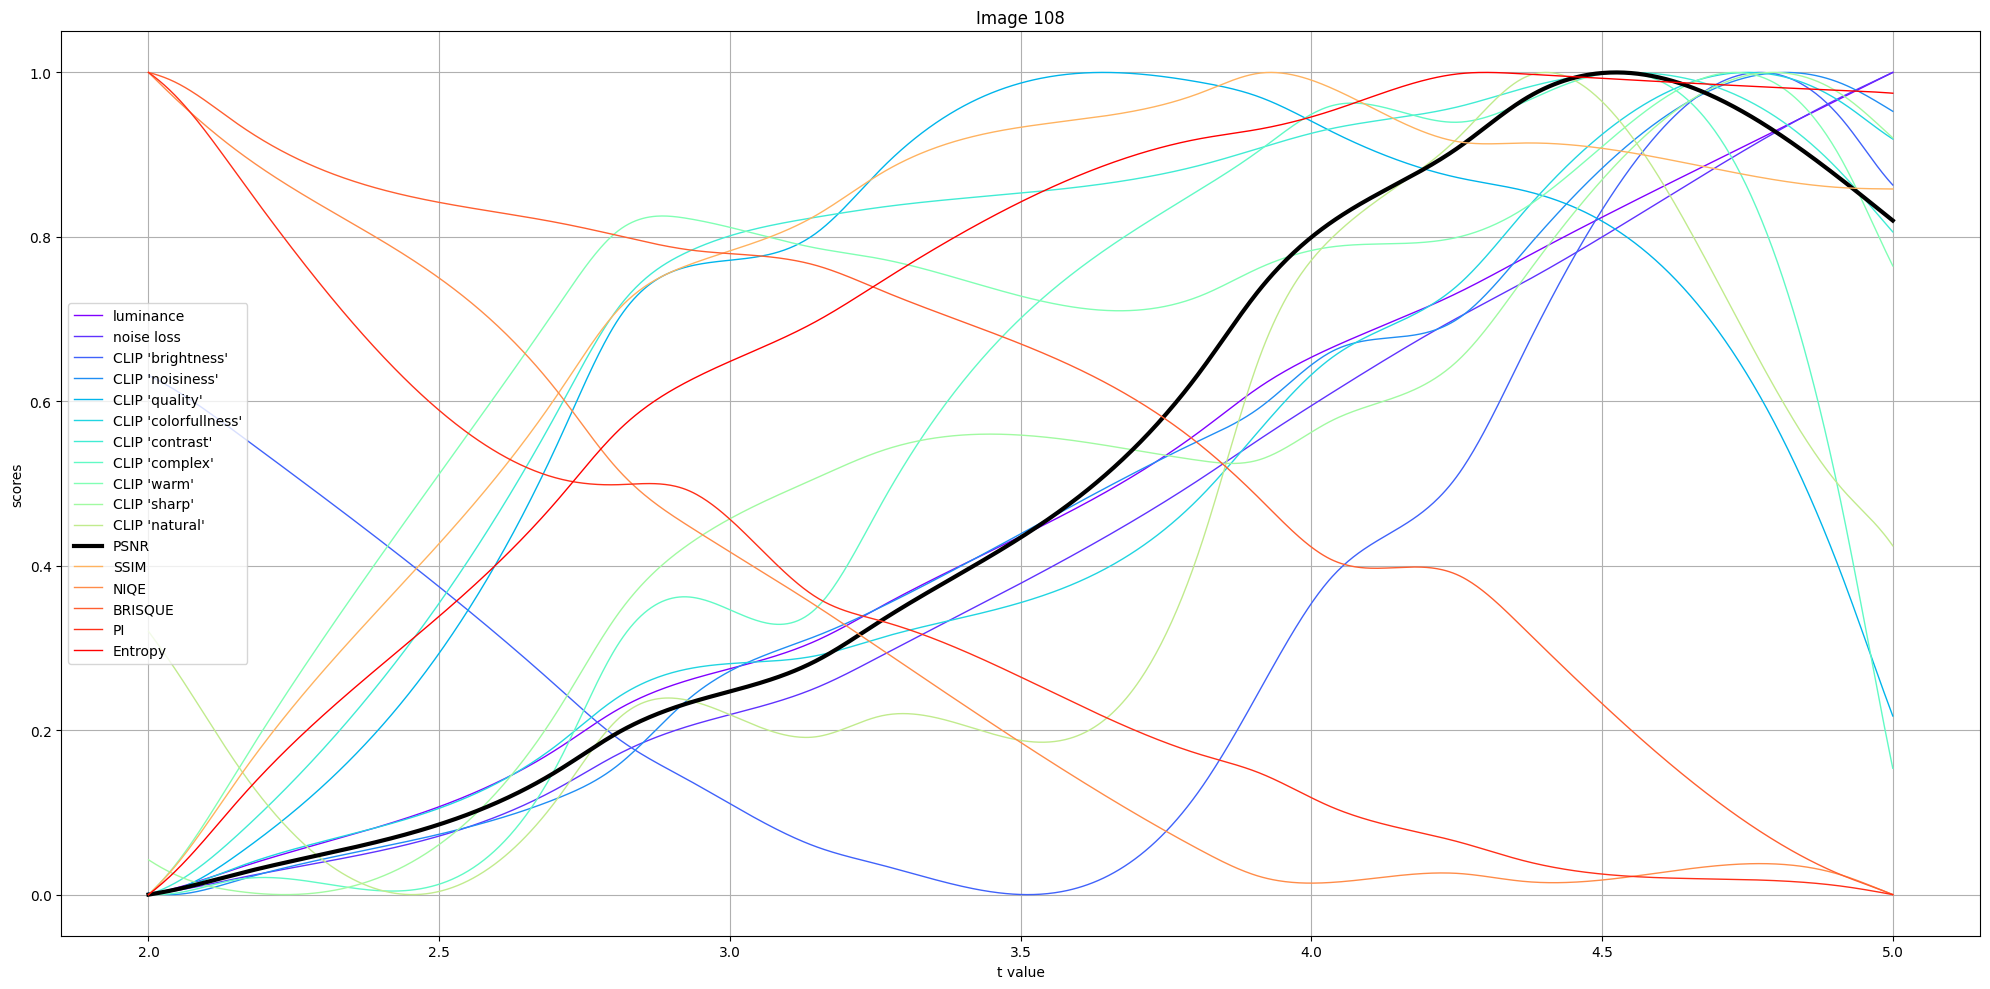

In [4]:
import os
import random
import matplotlib.pyplot as plt

random.seed(42)

CLIP_PROMPTS = [
    "brightness", "noisiness", "quality", "colorfullness",
    "contrast", "complex", "warm", "sharp",
    "natural",
]

num_images = len(trajectory_data)
# selected_images = random.sample(range(num_images), 5)
filenames = sorted(os.listdir('/home/soom/data/LOL/our485/low'))
selected_images = [filenames.index('100.png'), filenames.index('200.png'), filenames.index('231.png'),]

labels = [
    "luminance", "noise loss", "PSNR", "SSIM", "NIQE", "BRISQUE", "PI", "Entropy"
]
for i, clip_prompt in enumerate(CLIP_PROMPTS):
    labels.insert(i+2, f"CLIP '{clip_prompt}'")

colors = plt.cm.rainbow(np.linspace(0, 1, 17))

for img_idx in selected_images:
    datum = trajectory_data[img_idx]
    t_values = datum[:, 0]
    datum = datum[:, 1:]
    datum = (datum - datum.min(axis=0, keepdims=True)) / (datum.max(axis=0, keepdims=True) - datum.min(axis=0, keepdims=True))

    plt.figure(figsize=(20, 10))    
    for score_idx in range(17):
        scores = datum[:, score_idx]
        if score_idx == 11:
            plt.plot(t_values, scores, color='black', linewidth=3, label=labels[score_idx])
        else:
            plt.plot(t_values, scores, color=colors[score_idx], linewidth=1, label=labels[score_idx])
    
    plt.title(f'Image {img_idx}')
    plt.xlabel('t value')
    plt.ylabel('scores')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [3]:
print(labels)

['luminance', 'noise loss', "CLIP 'brightness'", "CLIP 'noisiness'", "CLIP 'quality'", "CLIP 'colorfullness'", "CLIP 'contrast'", "CLIP 'complex'", "CLIP 'warm'", "CLIP 'sharp'", "CLIP 'natural'", 'PSNR', 'SSIM', 'NIQE', 'BRISQUE', 'PI', 'Entropy']


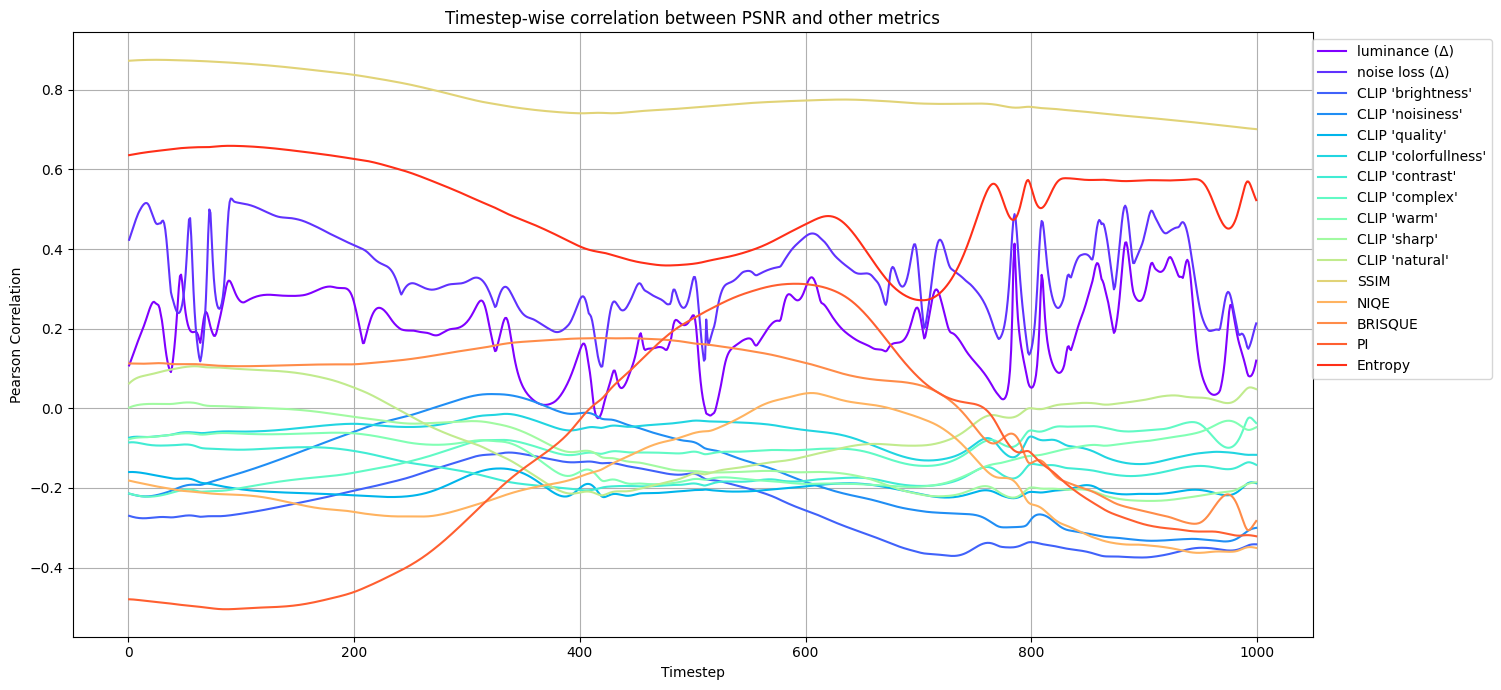

In [5]:
# 상관관계 계산 및 시각화
psnr = trajectory_data[:, :, 12]
other_indices = [i for i in range(1, 18) if i != 12]
others = trajectory_data[:, :, other_indices]  # (485, 1000, 16)

correlations = np.zeros((1000, 16))

for t in range(1, 1000):
    psnr_t = psnr[:, t]
    for i in range(2):
        other_t = others[:, t, i]
        prev_t = others[:, t-1, i]
        delta_t = other_t - prev_t
        corr = np.corrcoef(psnr_t, delta_t)[0, 1]
        correlations[t, i] = corr
    for i in range(2, 16):
        other_t = others[:, t, i]
        corr = np.corrcoef(psnr_t, other_t)[0, 1]
        correlations[t, i] = corr

timesteps = np.arange(1, 1000)

plt.figure(figsize=(15, 7))
for i, idx in enumerate(other_indices):
    plt.plot(timesteps, correlations[1:, i], label=labels[idx-1] if idx > 2 else labels[idx-1] + ' (Δ)', color=colors[i])

plt.title('Timestep-wise correlation between PSNR and other metrics')
plt.xlabel('Timestep')
plt.ylabel('Pearson Correlation')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1.0))
plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
'''
- 0 = t value
- 1 = lum mean
- 2 = noise loss
- 3:12 = CLIP scores
- 12 = psnr
- 13 = ssim
- 14:18 = non-reference metrics (NIQE, BRISQUE, PI, Entropy)
'''

# (485, 1000)
psnr = trajectory_data[:, :, 12]

luminance_delta = np.diff(trajectory_data[:, :, 1], axis=1, prepend=0)
noise_loss_delta = np.diff(trajectory_data[:, :, 2], axis=1, prepend=0)
entropy = trajectory_data[:, :, 17]

# features: (485, 1000, 3)
features = np.stack([
    entropy,
    noise_loss_delta,
    luminance_delta,
], axis=-1)
_min = features.min(axis=1, keepdims=True)
_max = features.max(axis=1, keepdims=True)
features = (features - _min) / (_max - _min)

In [7]:
from sklearn.linear_model import LinearRegression

# (485 * 1000, 3)
X = features[:, :, :].reshape(-1, 3)
y = psnr[:, :].reshape(-1)

model = LinearRegression()
model.fit(X, y)

weights = model.coef_
intercept = model.intercept_

print("가중치 (weights):", weights)
print("절편 (intercept):", intercept)

가중치 (weights): [ 0.58230562  0.86771274 -0.76247189]
절편 (intercept): 0.1271372526661138


In [8]:
from sklearn.metrics import r2_score

y_pred = model.predict(X)
print("Surrogate R²:", r2_score(y, y_pred))

Surrogate R²: 0.3346012197185181


In [9]:
surrogate1 = features[:, :, 0] * weights[0] + features[:, :, 1] * weights[1] + features[:, :, 2] * weights[2]
surrogate1_argmax = np.argmax(surrogate1, axis=1)

optimal_t = [trajectory_data[i, idx, 0] for i, idx in enumerate(surrogate1_argmax)]

In [11]:
from tqdm import tqdm
from network.conv_node import NODE
from misc import *

os.environ["CUDA_VISIBLE_DEVICES"] = '6'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
# CLODE model
model = NODE(device, (3, 400, 600), 32, augment_dim=0, time_dependent=True, adjoint=True)
model.eval()
model.to(device)
model.load_state_dict(torch.load("pth/lowlight.pth", map_location=device, weights_only=True), strict=False)

_IncompatibleKeys(missing_keys=[], unexpected_keys=['odefunc.norm.weight', 'odefunc.norm.bias', 'odefunc.condition.conv.0.weight', 'odefunc.condition.conv.0.bias', 'odefunc.condition.conv.2.weight', 'odefunc.condition.conv.2.bias', 'odefunc.condition.conv.4.weight', 'odefunc.condition.conv.4.bias', 'odefunc.cond_brightness.0.weight', 'odefunc.cond_brightness.2.weight', 'odeblock.odefunc.norm.weight', 'odeblock.odefunc.norm.bias', 'odeblock.odefunc.condition.conv.0.weight', 'odeblock.odefunc.condition.conv.0.bias', 'odeblock.odefunc.condition.conv.2.weight', 'odeblock.odefunc.condition.conv.2.bias', 'odeblock.odefunc.condition.conv.4.weight', 'odeblock.odefunc.condition.conv.4.bias', 'odeblock.odefunc.cond_brightness.0.weight', 'odeblock.odefunc.cond_brightness.2.weight'])

In [12]:
from pathlib import Path
IMAGE_PATH = Path('/home/soom/data/LOL/our485')
filenames = sorted(os.listdir(IMAGE_PATH / 'low'))

def load_image(filepath):
    img = cv2.imread(str(filepath))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = (np.asarray(img)/255.0)
    img = torch.from_numpy(img).float()
    img = img.permute(2, 0, 1).unsqueeze(0)
    
    return img.to(device)

total_psnr = 0
total_ssim = 0
for i in tqdm(range(num_images)):
    lq_img = load_image(IMAGE_PATH / 'low' / filenames[i])
    gt_img = load_image(IMAGE_PATH / 'high' / filenames[i])
    with torch.no_grad():
        integration_time = torch.tensor([0, optimal_t[i]]).float().to(device)
        pred = model(lq_img, integration_time, inference=True)['output']
        
    total_psnr += calculate_psnr(pred[0], gt_img[0])
    total_ssim += calculate_ssim(pred[0], gt_img[0])
print("Surrogate1 PSNR:", total_psnr / num_images)
print("Surrogate1 SSIM:", total_ssim / num_images)

100%|██████████| 485/485 [28:42<00:00,  3.55s/it]

Surrogate1 PSNR: 18.062607
Surrogate1 SSIM: 0.6741725304969209


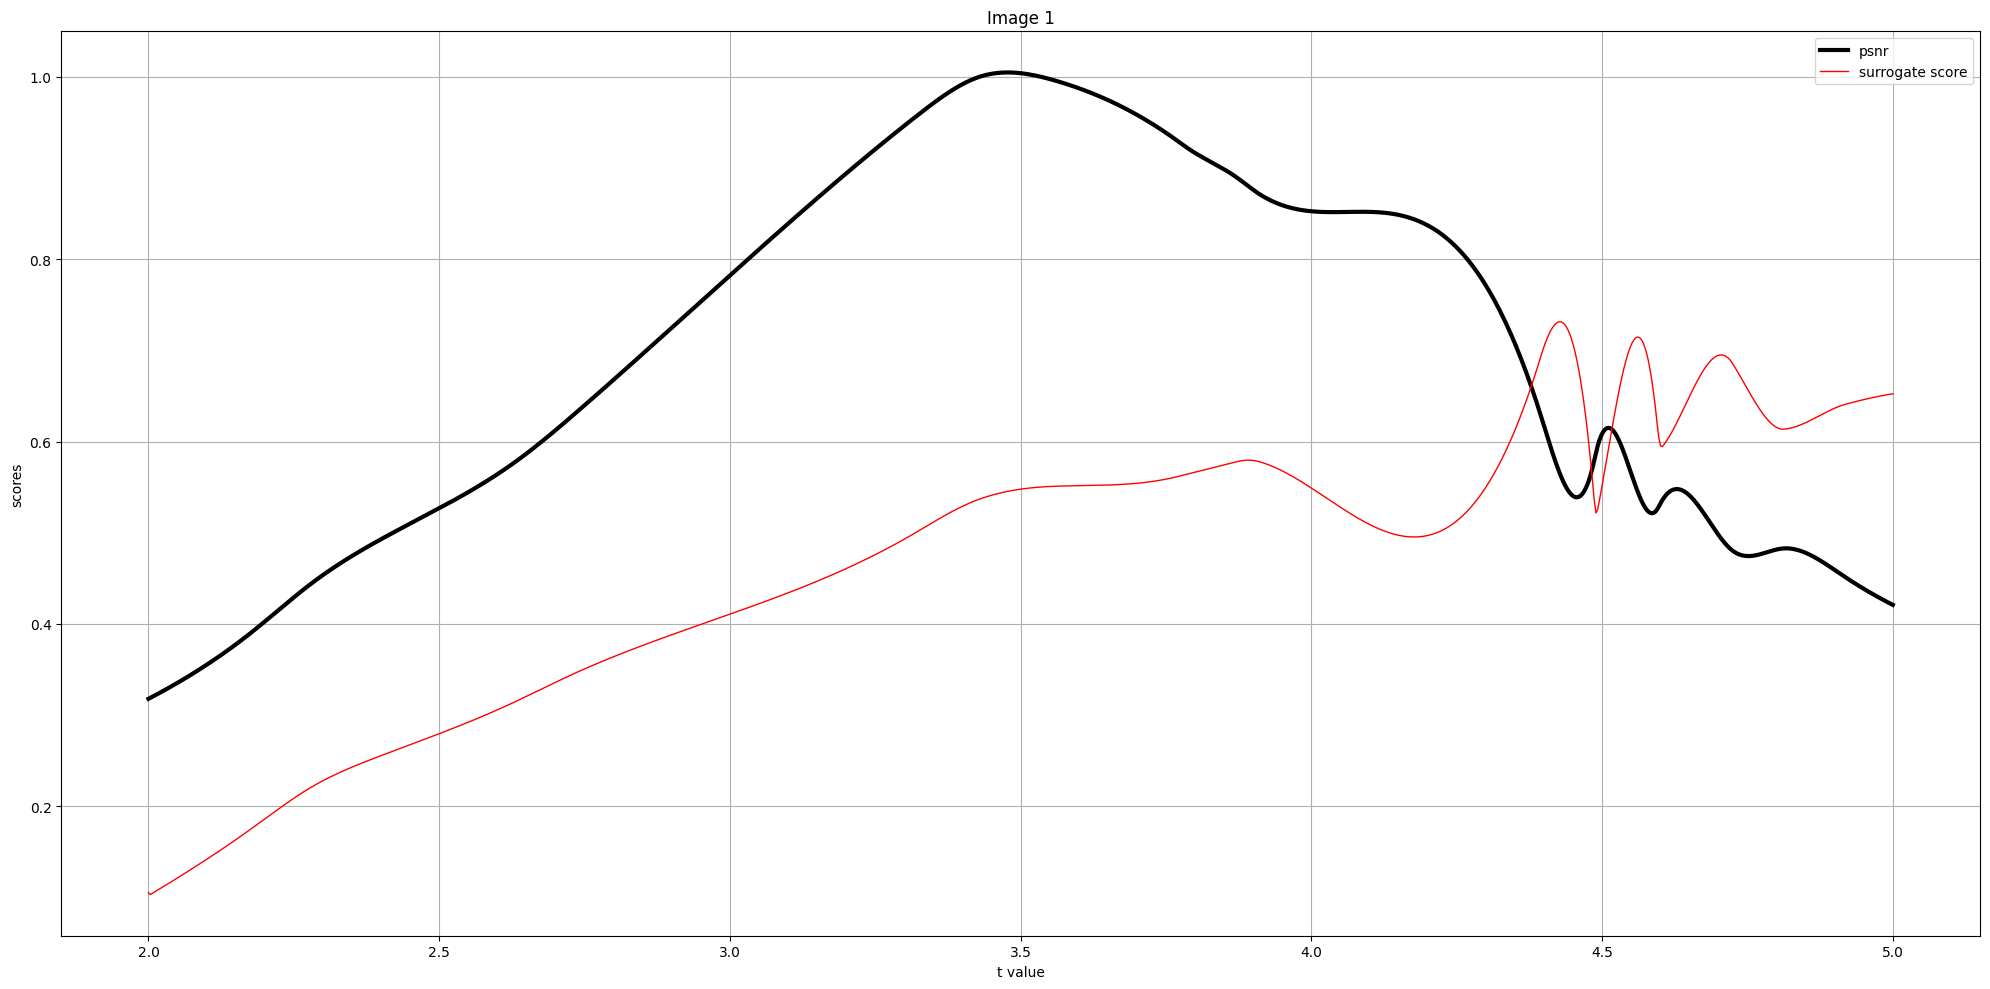

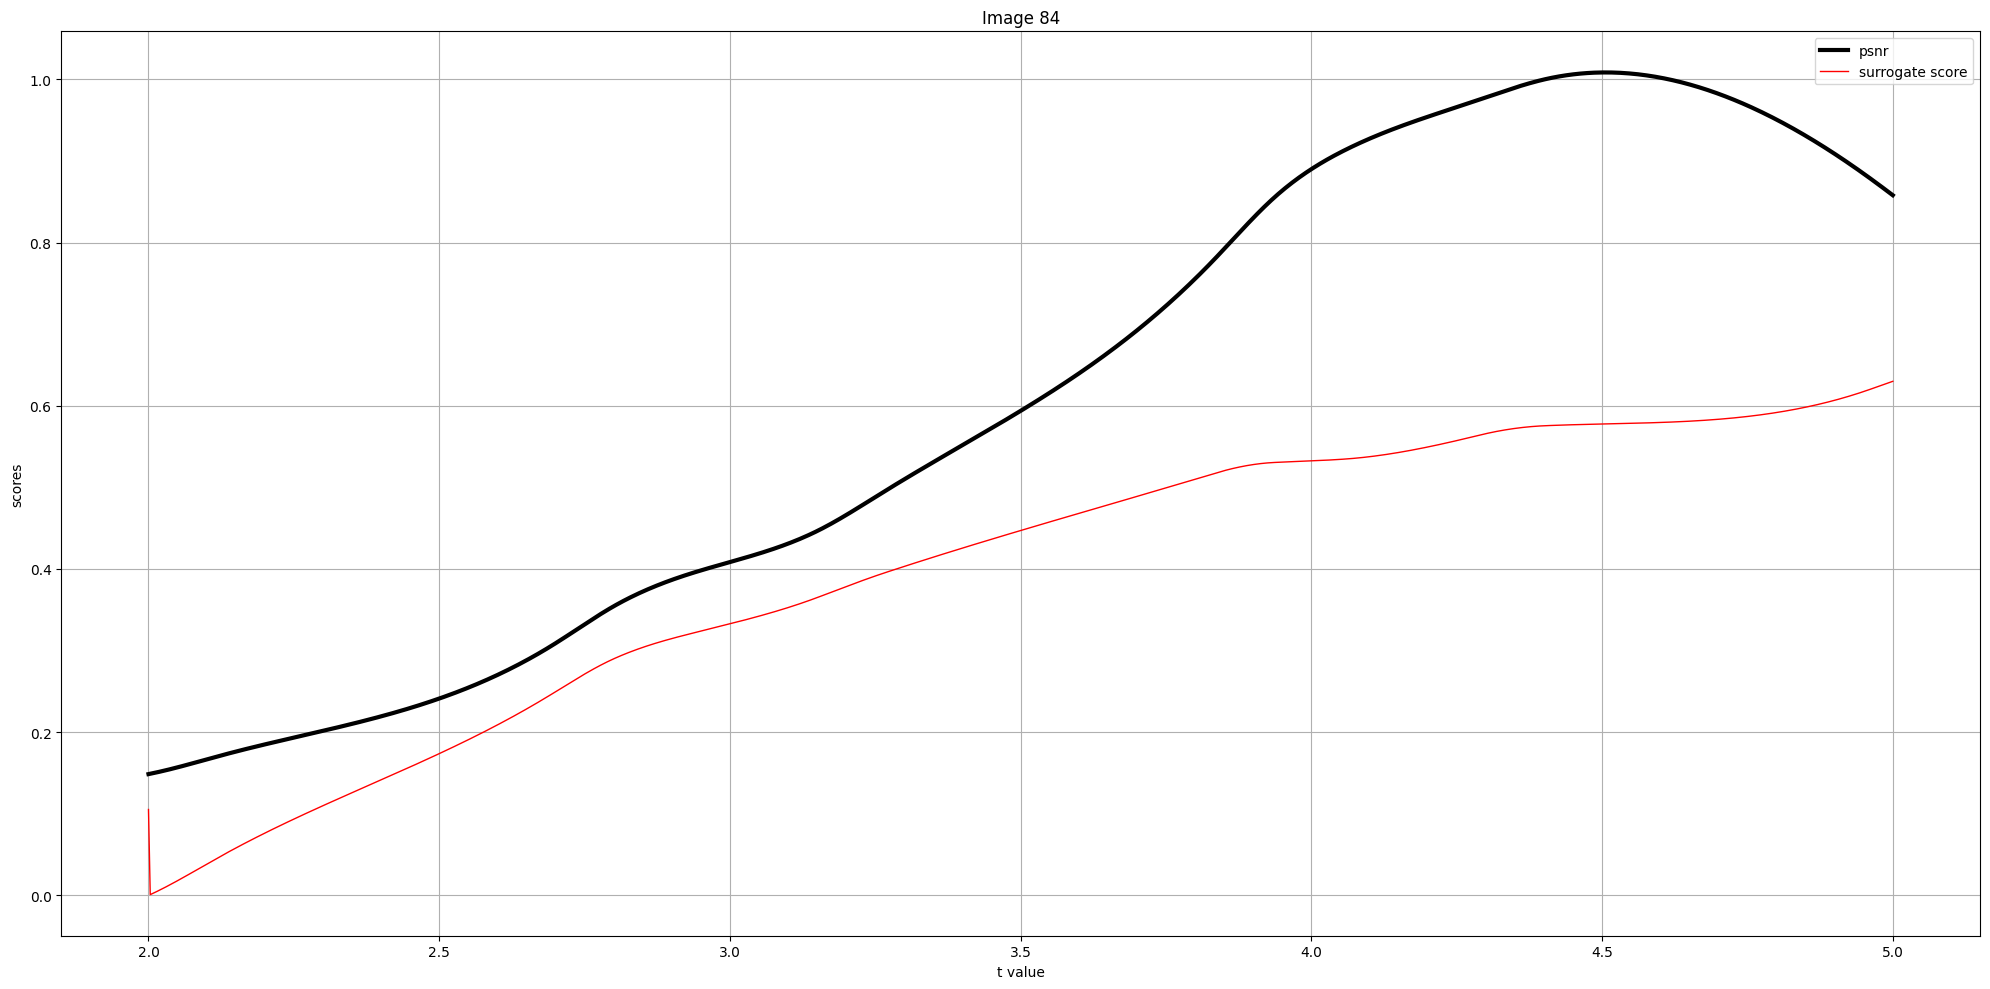

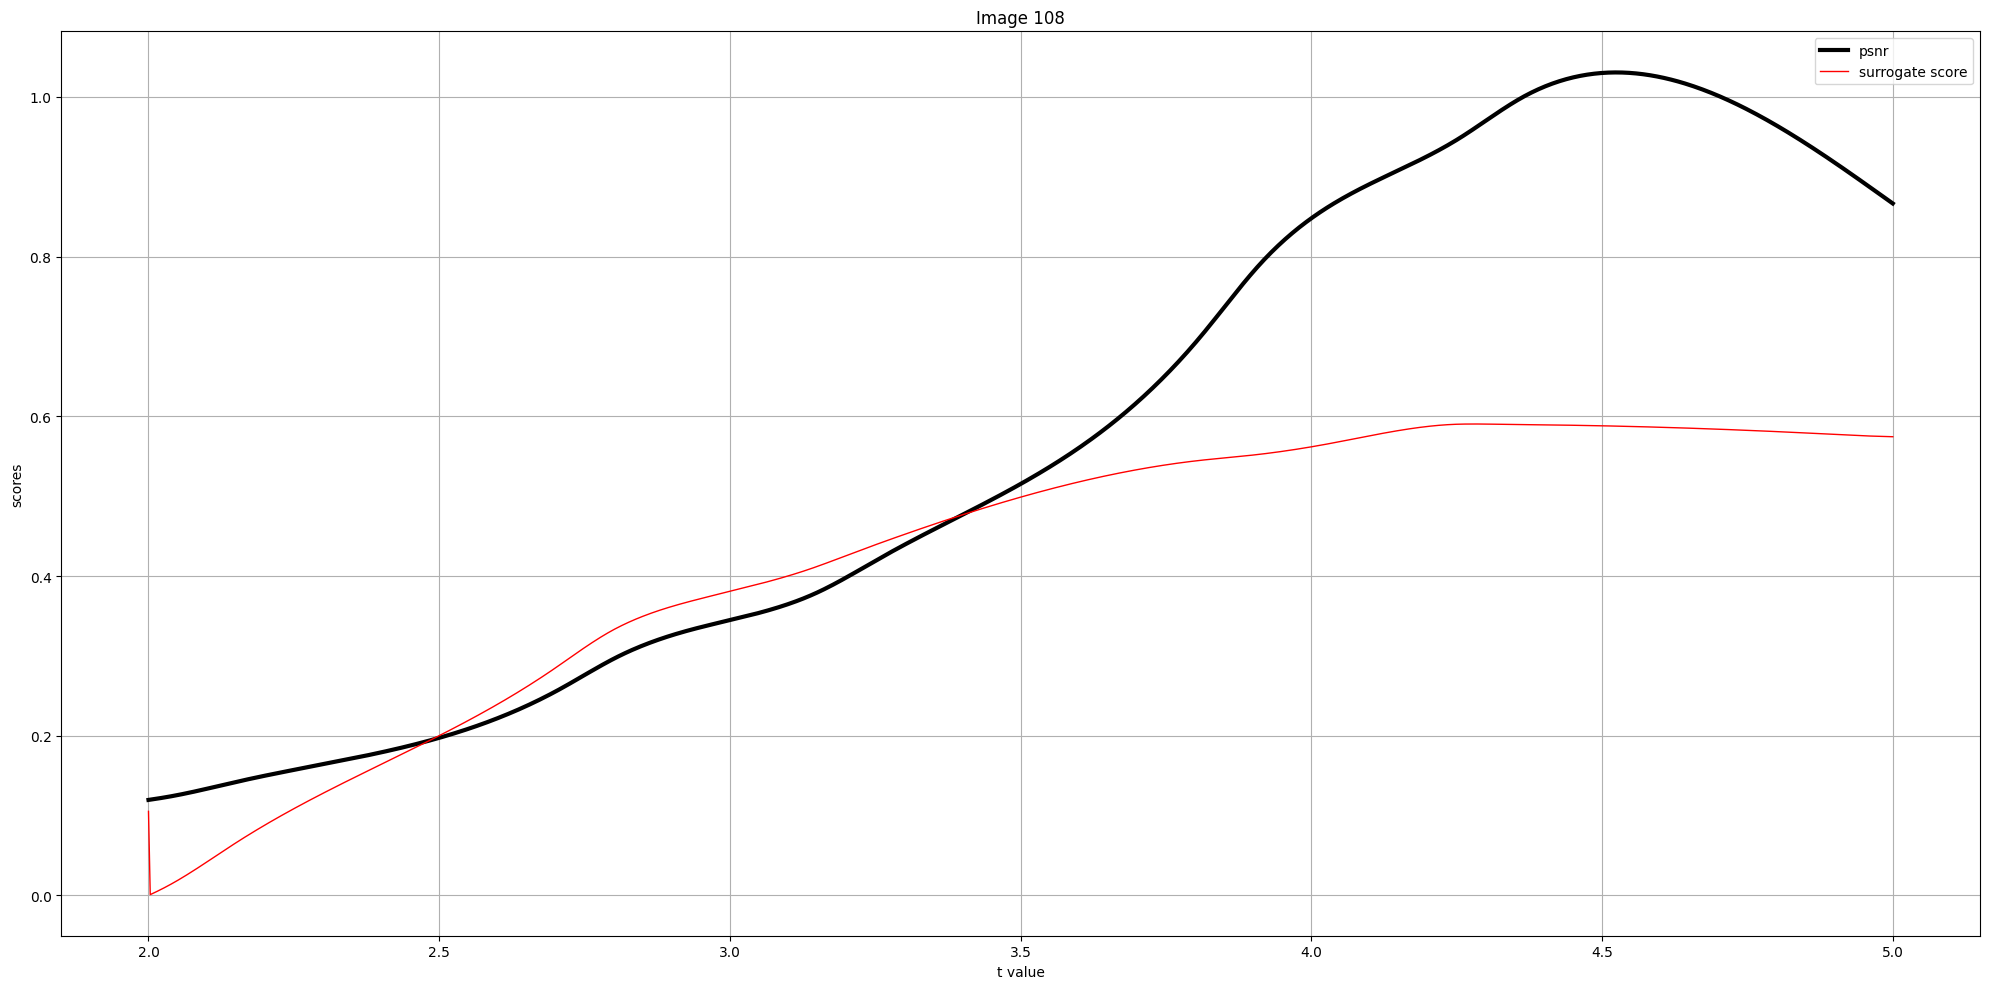

In [13]:
for img_idx in selected_images:
    datum = trajectory_data[img_idx]
    _psnr = datum[:, 12]
    _surrogate1 = features[img_idx, :, 0] * weights[0] + features[img_idx, :, 1] * weights[1] + features[img_idx, :, 2] * weights[2]

    plt.figure(figsize=(20, 10))    
    plt.plot(t_values, _psnr, color='black', linewidth=3, label='psnr')
    plt.plot(t_values, _surrogate1, color='red', linewidth=1, label='surrogate score')
    
    plt.title(f'Image {img_idx}')
    plt.xlabel('t value')
    plt.ylabel('scores')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
psnr = trajectory_data[:, :, 12]

features = []
luminance_delta = np.diff(trajectory_data[:, :, 1], axis=1, prepend=0)
noise_loss_delta = np.diff(trajectory_data[:, :, 2], axis=1, prepend=0)
clip_scores = trajectory_data[:, :, 3:12]
non_reference_metrics = trajectory_data[:, :, 14:]

features.append(luminance_delta)
features.append(noise_loss_delta)
for i in range(clip_scores.shape[2]):
    features.append(clip_scores[:, :, i])
for i in range(non_reference_metrics.shape[2]):
    features.append(non_reference_metrics[:, :, i])
    
features = np.stack(features, axis=-1)  # (485, 1000, 15)
_min = features.min(axis=1, keepdims=True)
_max = features.max(axis=1, keepdims=True)
features = (features - _min) / (_max - _min)

In [16]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# (485 * 1000, 3)
X = features[:, :, :].reshape(-1, 15)
y = psnr[:, :].reshape(-1)

models = {
    "Linear Regression": LinearRegression(fit_intercept=False),
    "Ridge Regression": Ridge(alpha=1.0, fit_intercept=False),
    "Lasso Regression": Lasso(alpha=0.1, fit_intercept=False)
}

weights = []
for name, model in models.items():
    model.fit(X, y)
    weights.append(model.coef_)
    
    print("가중치 (weights):", model.coef_)
    print("절편 (intercept):", model.intercept_)

    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    print(f"{name} R²:", r2)

가중치 (weights): [-1.11281968e+00  1.11657873e+00 -9.64573869e-02  1.41473750e-02
 -8.96469362e-02  1.79964514e-02 -4.46537953e-02  1.37627181e-02
  7.67307337e-03  6.95518681e-02  1.17532811e-04 -3.07850595e-02
  1.89893665e-01  1.49849473e-01  6.31437849e-01]
절편 (intercept): 0.0
Linear Regression R²: 0.4250229740731042
가중치 (weights): [-1.09279197e+00  1.09959161e+00 -9.65166818e-02  1.40778571e-02
 -8.96684194e-02  1.81574672e-02 -4.46802565e-02  1.37807080e-02
  7.68714780e-03  6.95608800e-02  1.76129272e-04 -3.07330682e-02
  1.89930958e-01  1.49765676e-01  6.31503359e-01]
절편 (intercept): 0.0
Ridge Regression R²: 0.4250219998751954
가중치 (weights): [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.57057444]
절편 (intercept): 0.0
Lasso Regression R²: 0.09786075203997846


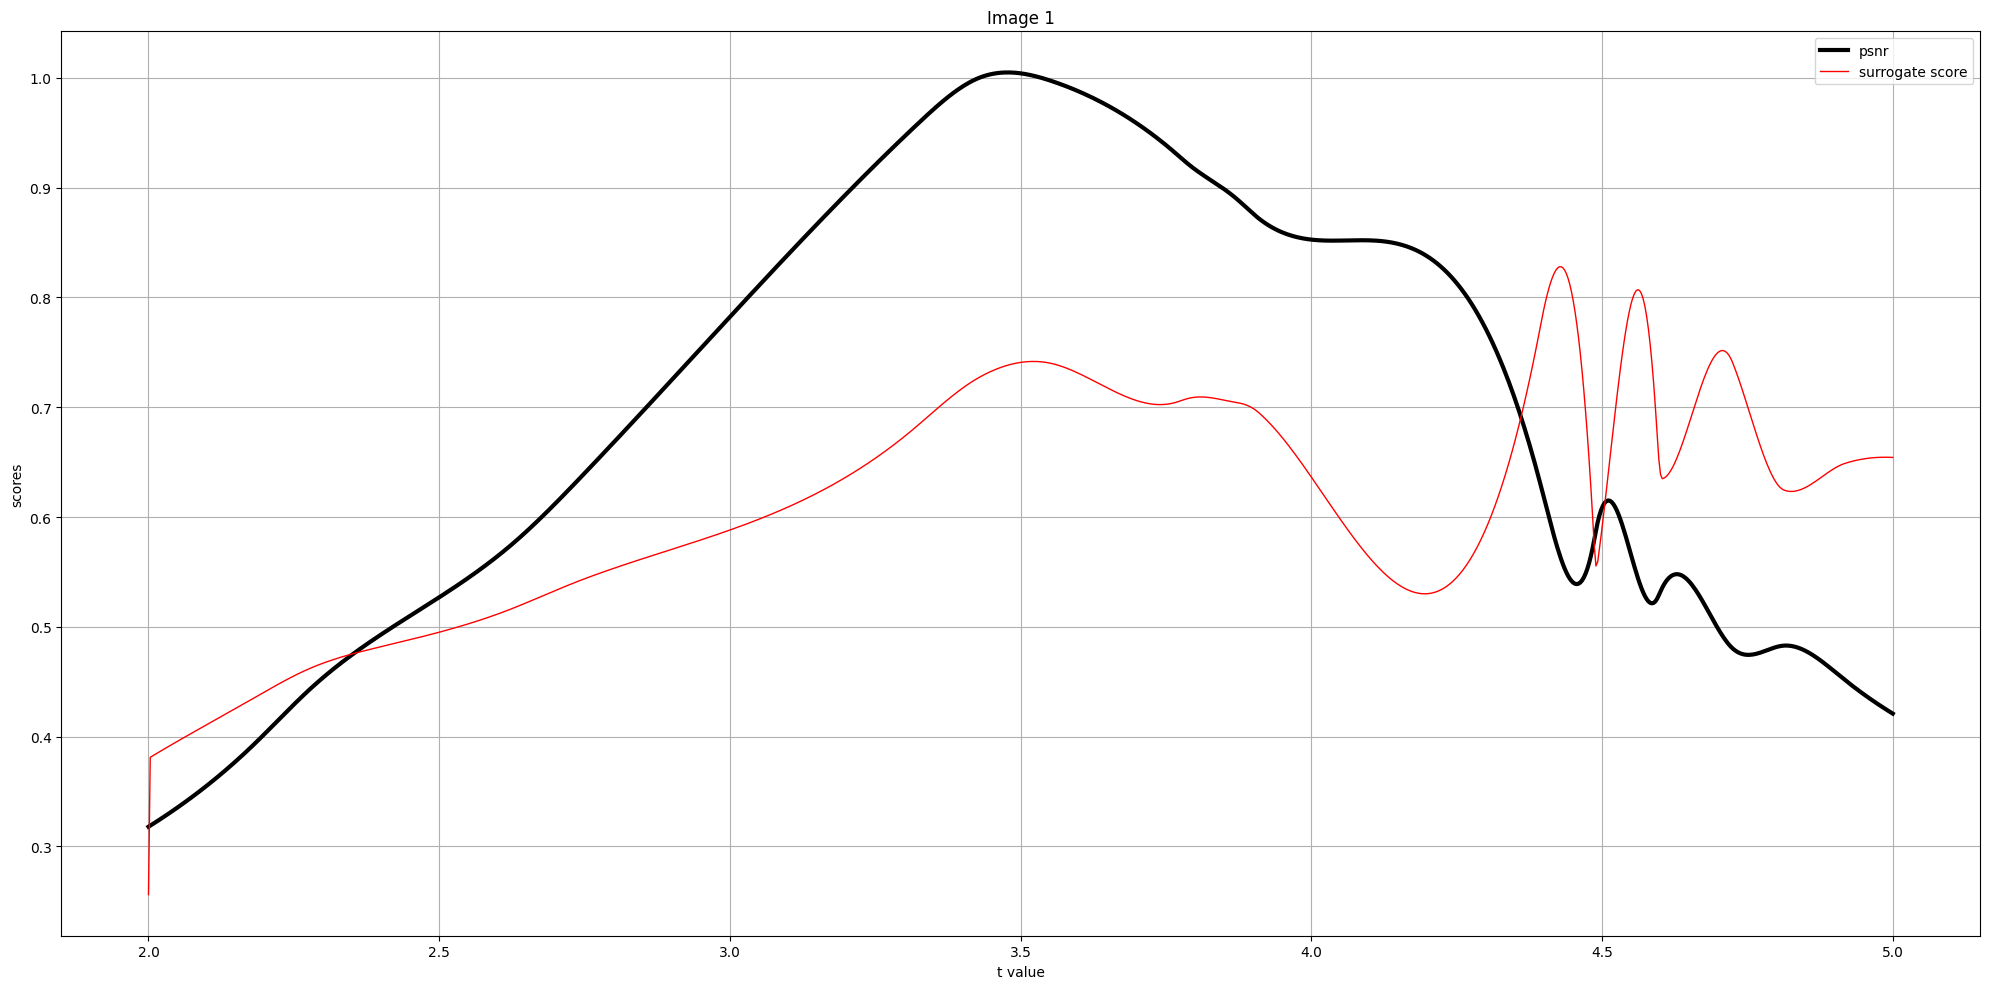

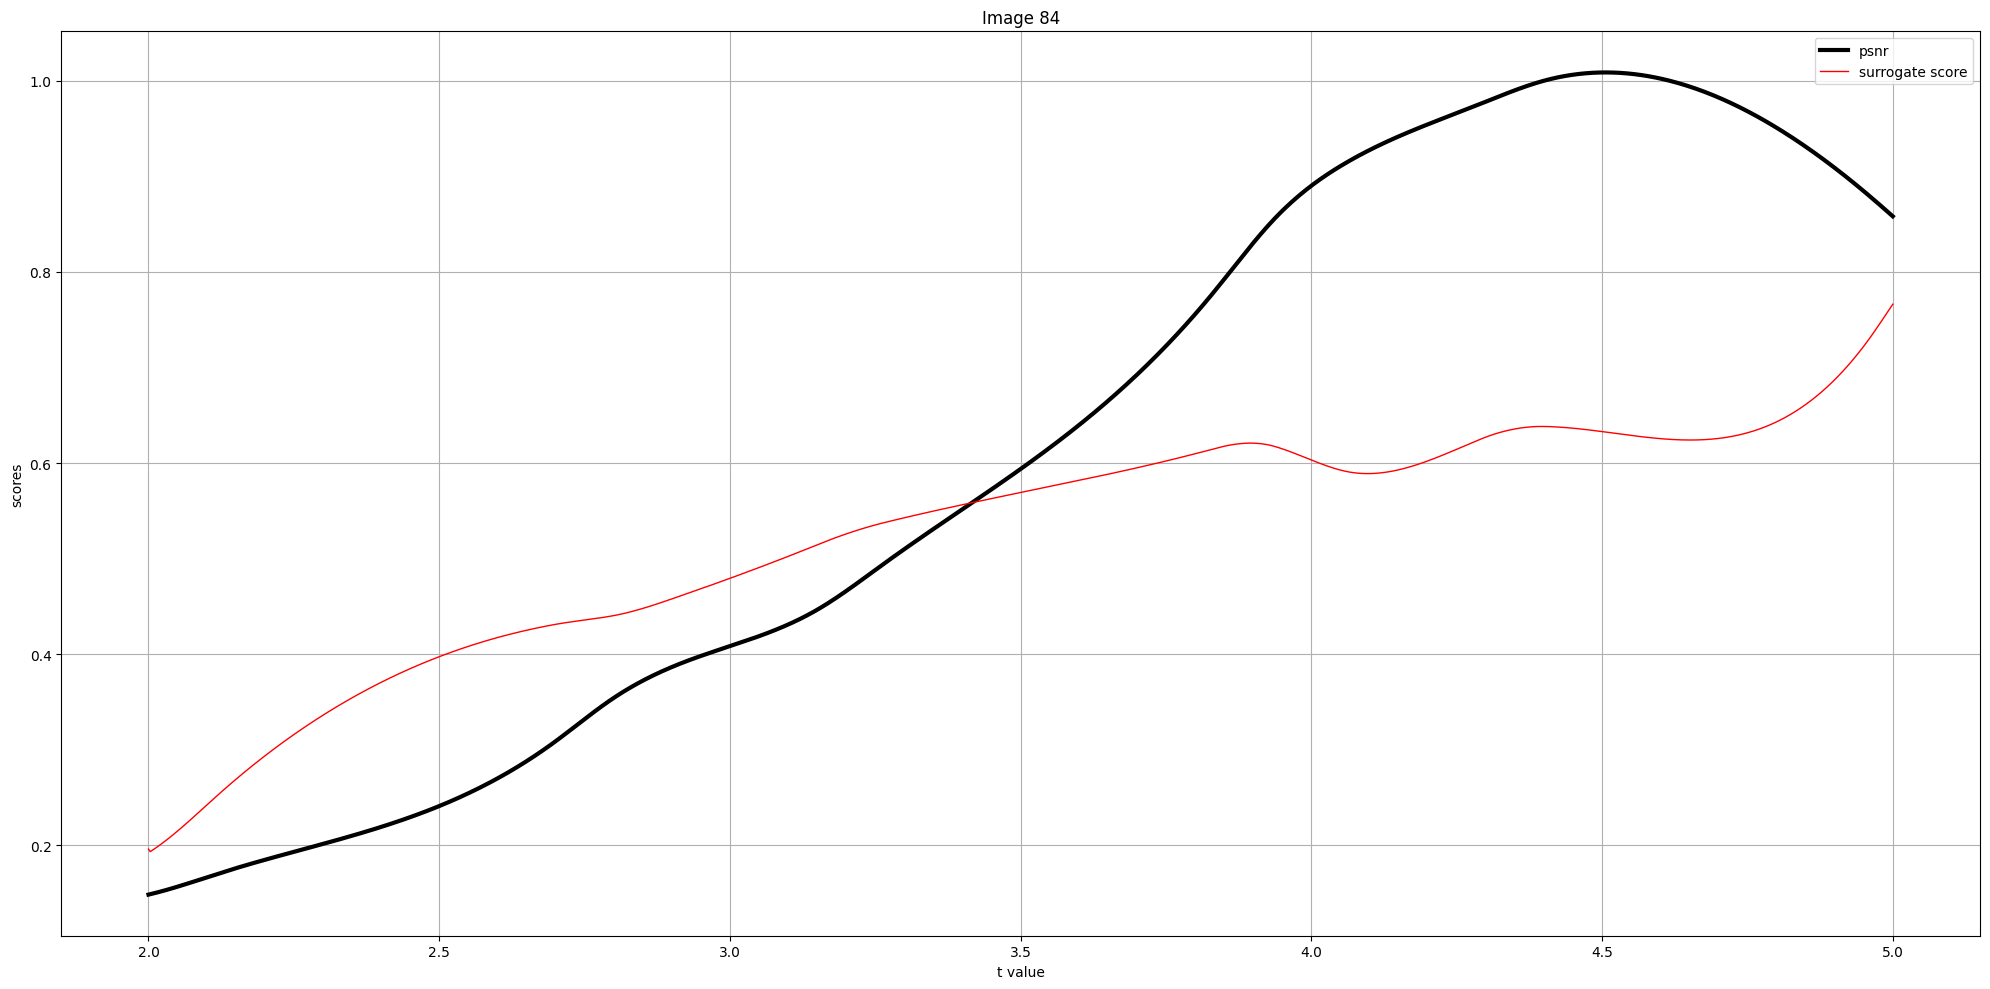

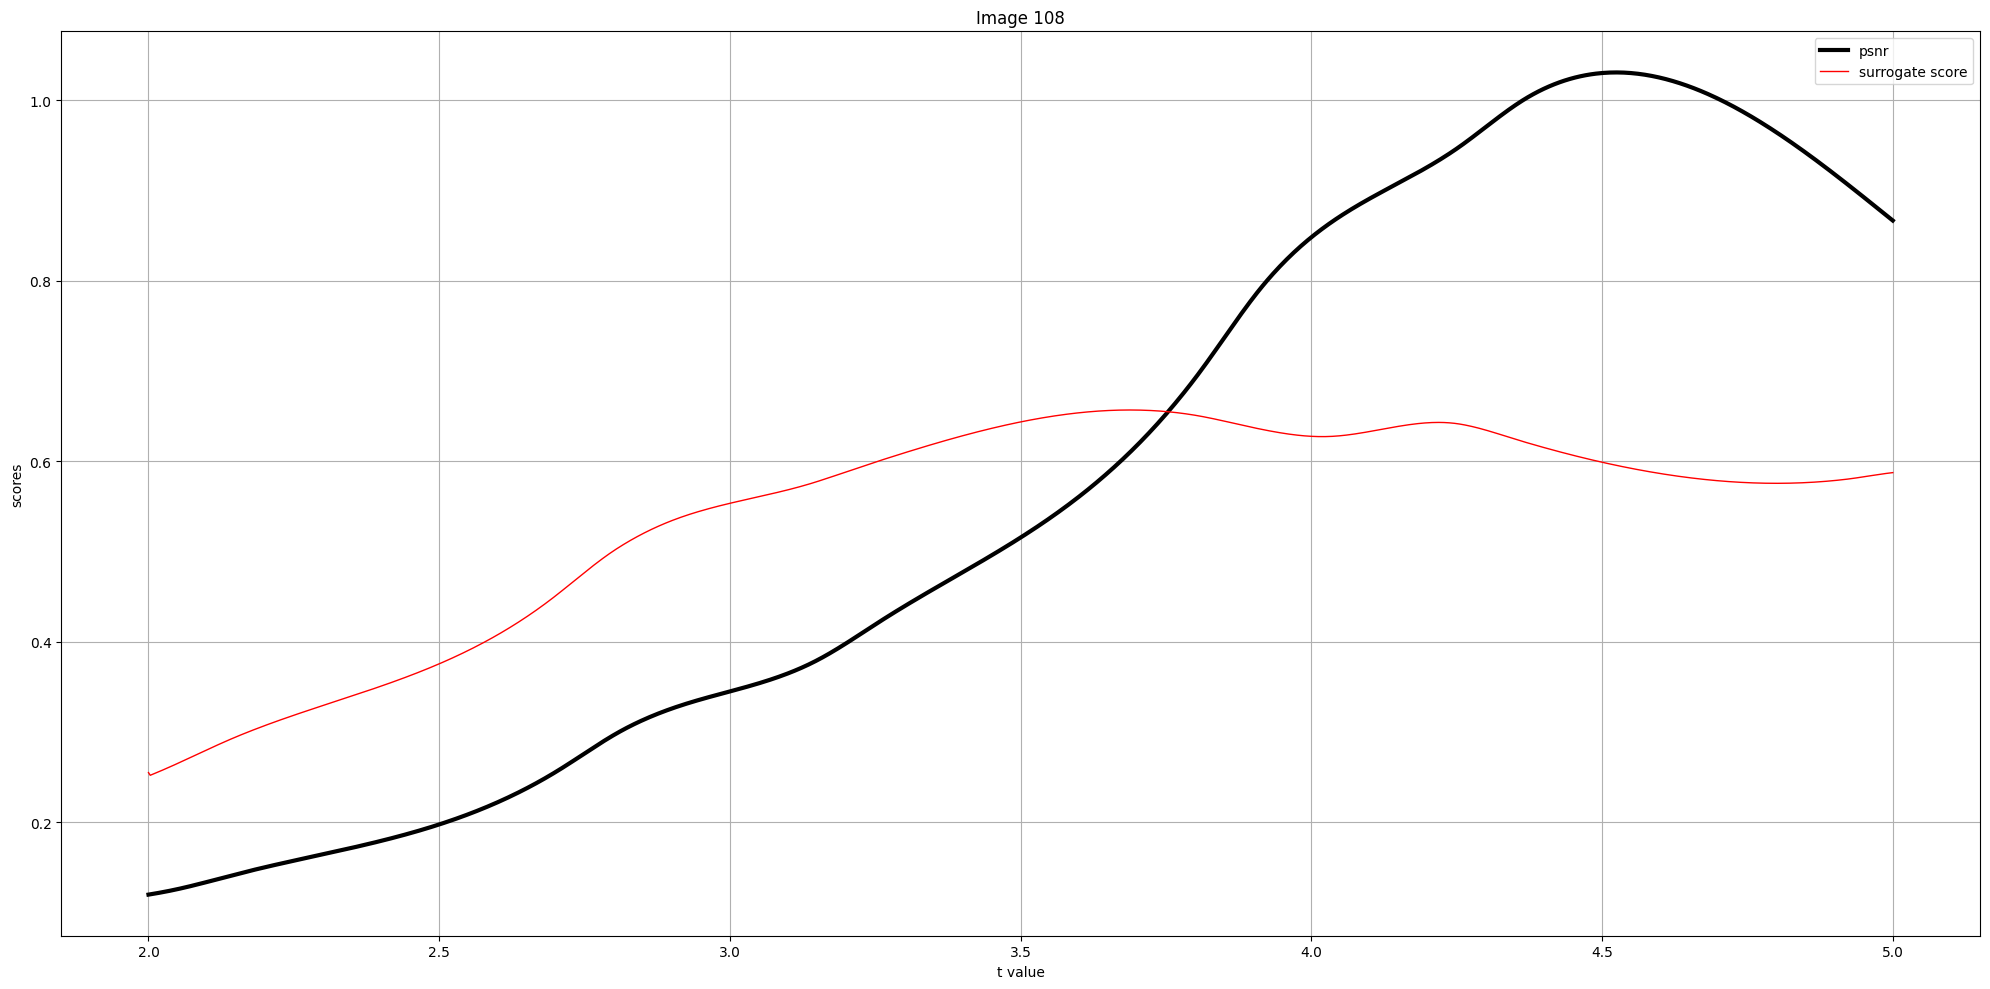

In [19]:
for img_idx in selected_images:
    datum = trajectory_data[img_idx]
    _psnr = datum[:, 12]
    _surrogate1 = np.zeros((1000,))
    for i in range(features.shape[2]):
        _surrogate1 += features[img_idx, :, i] * weights[0][i]

    plt.figure(figsize=(20, 10))    
    plt.plot(t_values, _psnr, color='black', linewidth=3, label='psnr')
    plt.plot(t_values, _surrogate1, color='red', linewidth=1, label='surrogate score')
    
    plt.title(f'Image {img_idx}')
    plt.xlabel('t value')
    plt.ylabel('scores')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [22]:
# t value's weighted sum
best_t_idx = np.zeros((num_images, 7))

active_metrics = [3, 4, 5, 14, 15, 16, 17]
for i, idx in enumerate(active_metrics):
    if idx in [14, 15, 16]:
        best_t_idx[:, i] = np.argmin(trajectory_data[:, :, idx], axis=1)
    else:
        best_t_idx[:, i] = np.argmax(trajectory_data[:, :, idx], axis=1)

best_t = np.zeros((num_images, 7))
for i in range(7):
    best_t[:, i] = [trajectory_data[j, int(best_t_idx[j, i]), 0] for j in range(num_images)]

surrogate_t = np.zeros((num_images,))
weights = [-0.0148, -0.0060, -0.0278, 0.1715, -0.1255, 0.2115, 0.6429]
for i in range(best_t.shape[1]):
    surrogate_t += best_t[:, i] * weights[i]

/tmp/ipykernel_1129235/433259096.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


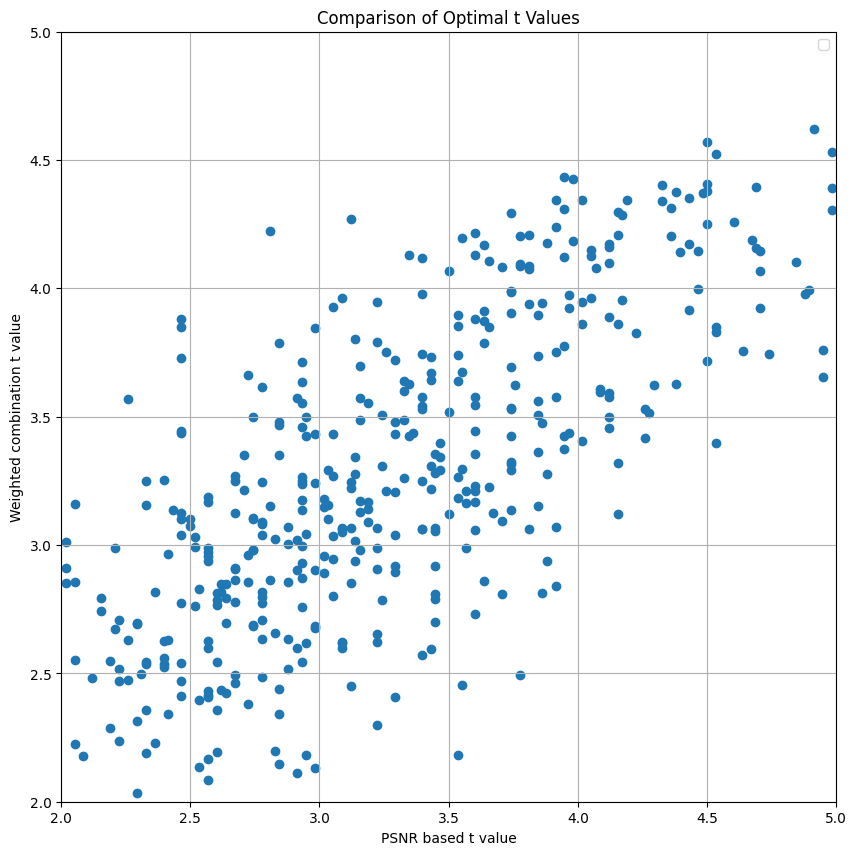

In [24]:
best_t = np.load('/home/soom/CLODE/interval_predictor/data/LOL/train_best_t_v2.npy', allow_pickle=True)[:, 0]

plt.figure(figsize=(10, 10))
plt.scatter(best_t, surrogate_t)

plt.xlabel('PSNR based t value')
plt.ylabel('Weighted combination t value')
plt.xlim(2.0, 5.0)
plt.ylim(2.0, 5.0)
plt.title('Comparison of Optimal t Values')
plt.legend()
plt.grid()
plt.show()

In [25]:
np.save('surrogate_bw_optimal_t.npy', surrogate_t)